# SOL Hourly Factor Research Regression

This notebook tests how SOL hourly returns move with contemporaneous crypto market factors, BTC volatility/risk proxies, hourly ETF market proxies, and slow macro variables aligned to the Binance hourly timeline. It is an explanatory research regression, so some predictors are same-hour factors rather than tradeable signals. Use the trading forecast notebook for strictly lagged, backtest-oriented signals.


## Setup and hourly data configuration


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Setup
project_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "refresh_data.py").exists() and (path / "data").exists()
)
time_interval = "1H"
raw_data_dir = project_root / "data" / "raw" / "binance_daily"
data_path = raw_data_dir / f"binance_spot_{time_interval}_ohlcv_combined.csv"
fred_data_path = project_root / "data" / "raw" / "fred_macro" / "fred_macro_1D_combined.csv"
yfinance_data_path = project_root / "data" / "raw" / "yfinance_market" / f"yfinance_market_{time_interval}_ohlcv_combined.csv"
btc_funding_path = project_root / "data" / "raw" / "binance_funding" / f"BTCUSDT_funding_rate_{time_interval}.csv"
btc_dvol_path = project_root / "data" / "raw" / "deribit_dvol" / f"BTC_DVOL_{time_interval}.csv"

coin_order = ["SOL", "BTC", "ETH", "BNB", "XRP", "DOGE", "SHIB", "PEPE"]
target = "SOL"
coin_colors = {
    "SOL": "purple",
    "BTC": "orange",
    "ETH": "grey",
    "BNB": "gold",
    "XRP": "navy",
    "DOGE": "red",
    "SHIB": "brown",
    "PEPE": "green",
}


## Load Binance hourly crypto data


In [2]:
# Load downloaded Binance spot OHLCV data
df = pd.read_csv(data_path, parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["coin"] = df["symbol"].str.replace("USDT", "", regex=False)

numeric_columns = ["open", "high", "low", "close", "volume"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

close_prices = df.pivot(index="timestamp", columns="coin", values="close").sort_index()
close_prices = close_prices[coin_order].replace([np.inf, -np.inf], np.nan)

open_prices = df.pivot(index="timestamp", columns="coin", values="open").sort_index()
high_prices = df.pivot(index="timestamp", columns="coin", values="high").sort_index()
low_prices = df.pivot(index="timestamp", columns="coin", values="low").sort_index()
volume_from = df.pivot(index="timestamp", columns="coin", values="volume").sort_index()

open_prices = open_prices[coin_order].replace([np.inf, -np.inf], np.nan)
high_prices = high_prices[coin_order].replace([np.inf, -np.inf], np.nan)
low_prices = low_prices[coin_order].replace([np.inf, -np.inf], np.nan)
volume_from = volume_from[coin_order].replace([np.inf, -np.inf], np.nan)


## Build hourly (log) returns and aligned external factors


In [3]:
# Build returns and hourly aligned factor inputs
raw_returns = close_prices.pct_change(fill_method=None)
raw_returns = raw_returns[coin_order].replace([np.inf, -np.inf], np.nan)
for coin in coin_order:
    first_valid_timestamp = close_prices[coin].first_valid_index()
    if first_valid_timestamp is not None:
        raw_returns.loc[first_valid_timestamp, coin] = 0.0

log_returns = np.log(close_prices / close_prices.shift(1))
log_returns = log_returns[coin_order].replace([np.inf, -np.inf], np.nan)
for coin in coin_order:
    first_valid_timestamp = close_prices[coin].first_valid_index()
    if first_valid_timestamp is not None:
        log_returns.loc[first_valid_timestamp, coin] = 0.0

fred_data = pd.read_csv(fred_data_path, parse_dates=["date"])
fred_data["date"] = pd.to_datetime(fred_data["date"], utc=True)
fred_data["value"] = pd.to_numeric(fred_data["value"], errors="coerce")
fred_features = fred_data.pivot(index="date", columns="factor", values="value").sort_index()
fred_features = fred_features.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

yfinance_data = pd.read_csv(yfinance_data_path, parse_dates=["date"])
yfinance_data["date"] = pd.to_datetime(yfinance_data["date"], utc=True).dt.floor("h")
yfinance_data["close"] = pd.to_numeric(yfinance_data["close"], errors="coerce")
yfinance_closes = yfinance_data.pivot(index="date", columns="factor", values="close").sort_index()
yfinance_closes = yfinance_closes.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)
yfinance_log_returns = np.log(yfinance_closes / yfinance_closes.shift(1)).replace([np.inf, -np.inf], np.nan)

btc_funding = pd.read_csv(btc_funding_path, parse_dates=["date"])
btc_funding["date"] = pd.to_datetime(btc_funding["date"], utc=True)
btc_funding["funding_rate_sum"] = pd.to_numeric(btc_funding["funding_rate_sum"], errors="coerce")
btc_funding = btc_funding.set_index("date").sort_index()
btc_funding = btc_funding.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

btc_dvol = pd.read_csv(btc_dvol_path)
dvol_time_column = "timestamp" if "timestamp" in btc_dvol.columns else "date"
btc_dvol[dvol_time_column] = pd.to_datetime(btc_dvol[dvol_time_column], utc=True)
btc_dvol["close"] = pd.to_numeric(btc_dvol["close"], errors="coerce")
btc_dvol = btc_dvol.set_index(dvol_time_column).sort_index()
btc_dvol = btc_dvol.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

cumulative_returns = np.exp(log_returns.cumsum()) - 1
simple_cumulative_returns = (1 + raw_returns).cumprod() - 1

print("Simple cumulative return:")
print(simple_cumulative_returns.tail())
print()


Simple cumulative return:
coin                            SOL       BTC       ETH       BNB       XRP  \
timestamp                                                                     
2026-07-29 04:00:00+00:00 -0.560232 -0.014325 -0.403479 -0.011009  0.835258   
2026-07-29 05:00:00+00:00 -0.558855 -0.012800 -0.401282 -0.009148  0.844090   
2026-07-29 06:00:00+00:00 -0.556460 -0.007125 -0.398890 -0.006557  0.847317   
2026-07-29 07:00:00+00:00 -0.555383 -0.005193 -0.397472 -0.005391  0.851732   
2026-07-29 08:00:00+00:00 -0.557538 -0.007982 -0.400374 -0.007757  0.844939   

coin                           DOGE      SHIB      PEPE  
timestamp                                                
2026-07-29 04:00:00+00:00 -0.402692 -0.708386 -0.737799  
2026-07-29 05:00:00+00:00 -0.402184 -0.705845 -0.735885  
2026-07-29 06:00:00+00:00 -0.400660 -0.706480 -0.734928  
2026-07-29 07:00:00+00:00 -0.399052 -0.705845 -0.735885  
2026-07-29 08:00:00+00:00 -0.402692 -0.707751 -0.737799  



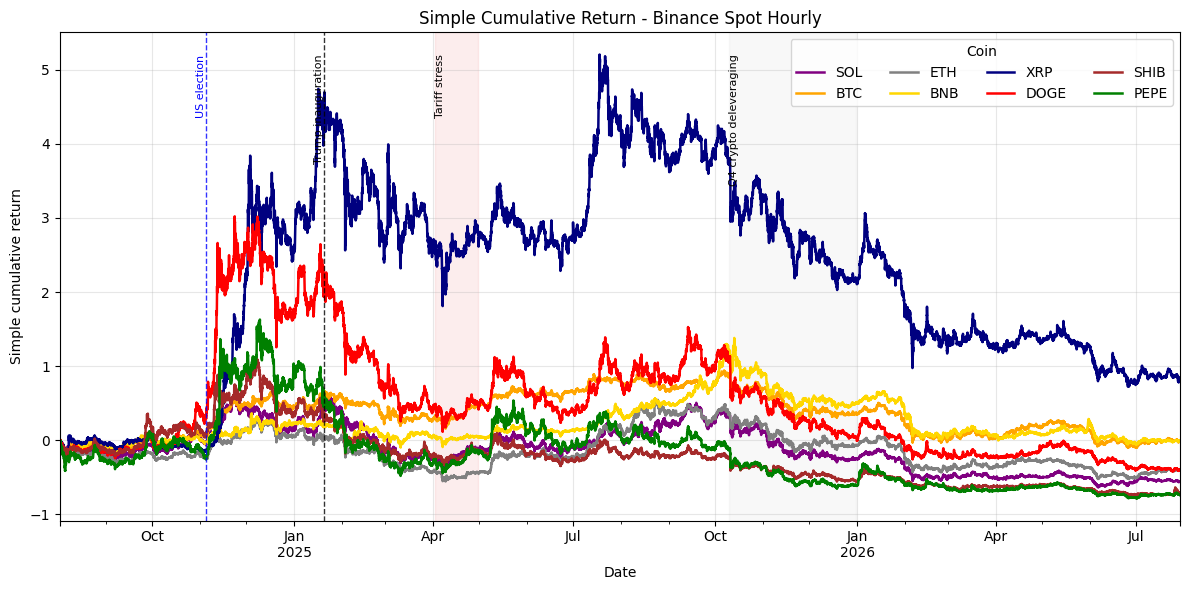

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
simple_cumulative_returns.plot(
    ax=ax,
    linewidth=1.8,
    color=[coin_colors.get(coin) for coin in simple_cumulative_returns.columns],
)

chart_start = simple_cumulative_returns.index.min()
chart_end = simple_cumulative_returns.index.max()
event_y = simple_cumulative_returns.max().max()

event_spans = [
    {"label": "Tariff stress", "start": "2025-04-02", "end": "2025-04-30", "color": "lightcoral"},
    {"label": "Q4 crypto deleveraging", "start": "2025-10-10", "end": "2025-12-31", "color": "lightgrey"},
]

event_lines = [
    {"label": "US election", "date": "2024-11-05", "color": "blue"},
    {"label": "Trump inauguration", "date": "2025-01-20", "color": "black"},
]

for event in event_spans:
    start = pd.Timestamp(event["start"], tz="UTC")
    end = pd.Timestamp(event["end"], tz="UTC")
    if end < chart_start or start > chart_end:
        continue
    visible_start = max(start, chart_start)
    visible_end = min(end, chart_end)
    ax.axvspan(visible_start, visible_end, color=event["color"], alpha=0.14)
    ax.text(visible_start, event_y, event["label"], rotation=90, va="top", ha="left", fontsize=8, color="black")

for event in event_lines:
    date = pd.Timestamp(event["date"], tz="UTC")
    if date < chart_start or date > chart_end:
        continue
    ax.axvline(date, color=event["color"], linewidth=1.0, linestyle="--", alpha=0.8)
    ax.text(date, event_y, event["label"], rotation=90, va="top", ha="right", fontsize=8, color=event["color"])

plt.title("Simple Cumulative Return - Binance Spot Hourly")
plt.xlabel("Date")
plt.ylabel("Simple cumulative return")
plt.grid(True, alpha=0.3)
plt.legend(title="Coin", ncols=4)
plt.tight_layout()
plt.show()


## Build explanatory feature matrix


In [5]:
# Build same-hour feature matrix for explanatory fit testing
# - target SOL is the current hourly log return
# - broad market returns are same-hour features
# - SOL/BTC technical factors are same-hour descriptive features
# - this matrix explains co-movement and market state, not tradable forecasts
features = pd.DataFrame(index=log_returns.index)

# Crypto features
features["BTC"] = log_returns["BTC"]
features["ETH"] = log_returns["ETH"]
features["BNB"] = log_returns["BNB"]
features["XRP"] = log_returns["XRP"]
features["DOGE"] = log_returns["DOGE"]
features["SHIB"] = log_returns["SHIB"]
features["PEPE"] = log_returns["PEPE"]

# SOL same-hour descriptive features
features["SOL_momentum_7h"] = log_returns["SOL"].rolling(7).sum()
features["SOL_momentum_14h"] = log_returns["SOL"].rolling(14).sum()
features["SOL_volatility_7h"] = log_returns["SOL"].rolling(7).std()
features["SOL_volatility_14h"] = log_returns["SOL"].rolling(14).std()
features["SOL_volume_change"] = np.log(volume_from["SOL"] / volume_from["SOL"].shift(1))
features["SOL_range"] = (high_prices["SOL"] - low_prices["SOL"]) / close_prices["SOL"]

# BTC same-hour descriptive features
features["BTC_volatility_14h"] = log_returns["BTC"].rolling(14).std()
features["BTC_range"] = (high_prices["BTC"] - low_prices["BTC"]) / close_prices["BTC"]
features["BTC_funding_rate_sum"] = btc_funding["funding_rate_sum"]

if btc_dvol["close"].notna().sum() >= 500:
    features["BTC_DVOL_change"] = btc_dvol["close"].diff()
else:
    print("Skipping BTC_DVOL_change: insufficient hourly overlap.")

# Slow macro features, forward-filled from FRED
features["M2_30d_change"] = np.log(fred_features["m2_money_supply"] / fred_features["m2_money_supply"].shift(24 * 30))
features["SOFR_change"] = fred_features["sofr"].diff()
features["DFF_change"] = fred_features["effective_fed_funds_rate"].diff()

# Hourly market proxy ETF features
features["QQQ"] = yfinance_log_returns["nasdaq_100_etf"]
features["SPY"] = yfinance_log_returns["sp500_etf"]
features["IEF"] = yfinance_log_returns["treasury_7_10y_etf"]
features["TLT"] = yfinance_log_returns["treasury_20y_etf"]
features["UUP"] = yfinance_log_returns["us_dollar_index_proxy"]
features["HYG"] = yfinance_log_returns["high_yield_credit_proxy"]
features["VXX"] = yfinance_log_returns["vix_futures_proxy"]

# SOL same-hour technical indicators
features["SOL_SMA12h"] = log_returns["SOL"].rolling(12).mean()
features["SOL_SMA26h"] = log_returns["SOL"].rolling(26).mean()

sol_close_change = close_prices["SOL"].diff()
sol_gain = sol_close_change.clip(lower=0)
sol_loss = -sol_close_change.clip(upper=0)
sol_avg_gain_14h = sol_gain.rolling(14).mean()
sol_avg_loss_14h = sol_loss.rolling(14).mean()
features["SOL_RSI_14h"] = 100 - (100 / (1 + sol_avg_gain_14h / sol_avg_loss_14h))

sol_bb_middle_20h = close_prices["SOL"].rolling(20).mean()
sol_bb_std_20h = close_prices["SOL"].rolling(20).std()
sol_bb_upper_20h = sol_bb_middle_20h + 2 * sol_bb_std_20h
sol_bb_lower_20h = sol_bb_middle_20h - 2 * sol_bb_std_20h
features["SOL_BB_percent_b_20h"] = (
    (close_prices["SOL"] - sol_bb_lower_20h) / (sol_bb_upper_20h - sol_bb_lower_20h)
)

model_data = pd.concat([log_returns[target].rename(target), features], axis=1).dropna()

print("Model data:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.expand_frame_repr", False,
):
    print(model_data.head(10))

print()
print("Dependent Variable is current-hour SOL log return.")
print("Predictors are same-hour explanatory features, including crypto returns, market proxies, macro context, funding, DVOL, and SOL/BTC technical state.")
print("This research matrix explains co-movement and market state. It is not a tradable forecast matrix.")

print("Predictors use Binance spot hourly OHLCV plus hourly yfinance ETF proxies.")
print("FRED macro series are lower frequency and forward-filled onto hourly timestamps.")


Model data:
                                SOL       BTC       ETH       BNB       XRP      DOGE      SHIB      PEPE  SOL_momentum_7h  SOL_momentum_14h  SOL_volatility_7h  SOL_volatility_14h  SOL_volume_change  SOL_range  BTC_volatility_14h  BTC_range  BTC_funding_rate_sum  BTC_DVOL_change  M2_30d_change  SOFR_change  DFF_change  QQQ  SPY  IEF  TLT  UUP  HYG  VXX  SOL_SMA12h  SOL_SMA26h  SOL_RSI_14h  SOL_BB_percent_b_20h
timestamp                                                                                                                                                                                                                                                                                                                                                                                                                    
2024-10-01 00:00:00+00:00  0.010957  0.003222  0.006355  0.007900  0.014291  0.013394  0.036876  0.014238        -0.009297         -0.001102           0.009237 

In [6]:
## Feature correlation diagnostics
print(features.isna().sum().sort_values(ascending=False).to_string())
print()

feature_count = features.shape[1]
print(f"Number of model features: {feature_count}")

M2_30d_change           1440
SOL_SMA26h                25
SOL_BB_percent_b_20h      19
IEF                       14
SPY                       14
TLT                       14
UUP                       14
QQQ                       14
SOL_RSI_14h               14
HYG                       14
VXX                       14
SOL_volatility_14h        13
BTC_volatility_14h        13
SOL_momentum_14h          13
SOL_SMA12h                11
SOL_volatility_7h          6
SOL_momentum_7h            6
SOFR_change                1
SOL_volume_change          1
BTC_DVOL_change            1
DFF_change                 1
BTC_range                  0
PEPE                       0
BTC                        0
SOL_range                  0
ETH                        0
BNB                        0
XRP                        0
DOGE                       0
SHIB                       0
BTC_funding_rate_sum       0

Number of model features: 31


## Feature correlation diagnostics


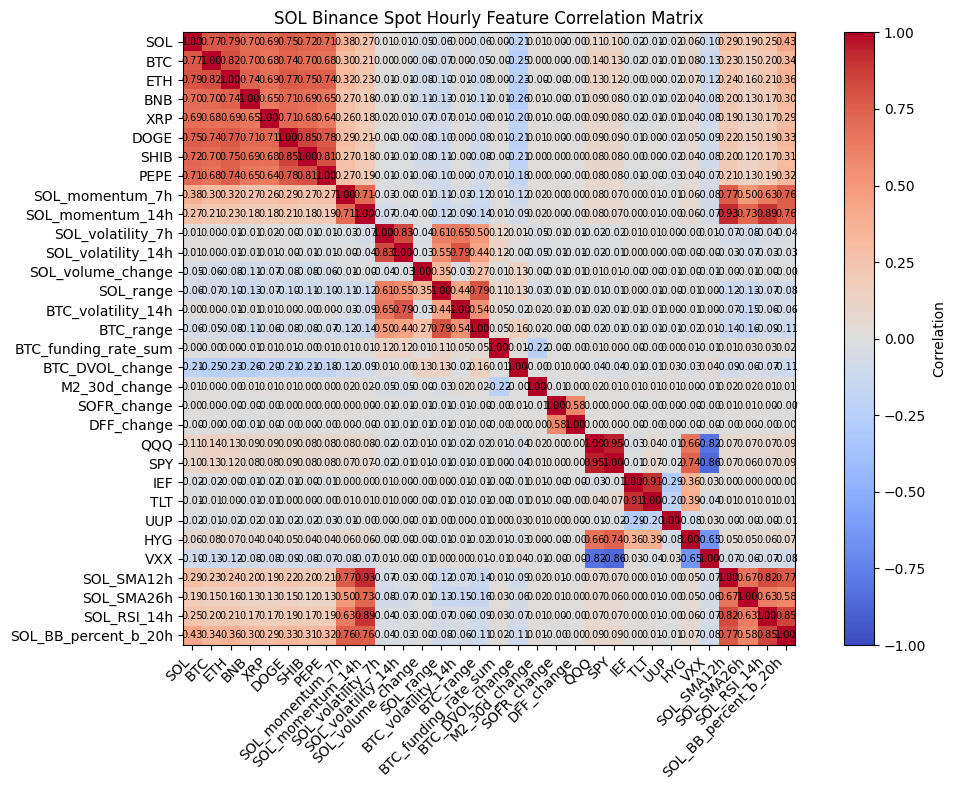

In [7]:
# Correlation matrix
correlation_matrix = model_data.corr()

plt.figure(figsize=(11, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("SOL Binance Spot Hourly Feature Correlation Matrix")

for row_index, row_name in enumerate(correlation_matrix.index):
    for column_index, column_name in enumerate(correlation_matrix.columns):
        value = correlation_matrix.loc[row_name, column_name]
        plt.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

## Fit explanatory regression models


In [8]:
# Linear, Ridge, and ElasticNet regression
feature_columns = list(features.columns)
split_idx = int(len(model_data) * 0.8)

train_data = model_data.iloc[:split_idx]
test_data = model_data.iloc[split_idx:]

X_train = sm.add_constant(train_data[feature_columns], has_constant="add")
y_train = train_data[target]
X_test = sm.add_constant(test_data[feature_columns], has_constant="add")
y_test = test_data[target]

model = sm.OLS(y_train, X_train).fit()
y_pred = model.predict(X_test)

train_r2 = model.rsquared
adjusted_train_r2 = 1 - (1 - train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
test_r2 = r2_score(y_test, y_pred)
adjusted_test_r2 = 1 - (1 - test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
pred_corr = np.corrcoef(y_test, y_pred)[0, 1]

cv_r2s = []
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(train_data):
    cv_X_train = sm.add_constant(train_data.iloc[train_idx][feature_columns], has_constant="add")
    cv_y_train = train_data.iloc[train_idx][target]
    cv_X_val = sm.add_constant(train_data.iloc[val_idx][feature_columns], has_constant="add")
    cv_y_val = train_data.iloc[val_idx][target]
    cv_model = sm.OLS(cv_y_train, cv_X_train).fit()
    cv_pred = cv_model.predict(cv_X_val)
    cv_r2s.append(r2_score(cv_y_val, cv_pred))

coefficients = model.params.rename("coefficient")


print()
print(model.summary())

ridge_X_train = train_data[feature_columns]
ridge_X_test = test_data[feature_columns]
ridge_alphas = [0.01, 0.1, 1, 10, 100, 300, 1000, 3000, 10000]

ridge_cv_results = []

for alpha in ridge_alphas:
    alpha_cv_r2s = []
    for train_idx, val_idx in tscv.split(train_data):
        cv_X_train = train_data.iloc[train_idx][feature_columns]
        cv_y_train = train_data.iloc[train_idx][target]
        cv_X_val = train_data.iloc[val_idx][feature_columns]
        cv_y_val = train_data.iloc[val_idx][target]
        cv_ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        cv_ridge_model.fit(cv_X_train, cv_y_train)
        alpha_cv_r2s.append(r2_score(cv_y_val, cv_ridge_model.predict(cv_X_val)))
    ridge_cv_results.append({"alpha": alpha, "cv_r2_mean": np.mean(alpha_cv_r2s)})

ridge_cv_results = pd.DataFrame(ridge_cv_results)
best_ridge_alpha = ridge_cv_results.loc[ridge_cv_results["cv_r2_mean"].idxmax(), "alpha"]
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=best_ridge_alpha))
ridge_model.fit(ridge_X_train, y_train)
ridge_y_pred = ridge_model.predict(ridge_X_test)

ridge_train_r2 = ridge_model.score(ridge_X_train, y_train)
ridge_adjusted_train_r2 = 1 - (1 - ridge_train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
ridge_test_r2 = r2_score(y_test, ridge_y_pred)
ridge_adjusted_test_r2 = 1 - (1 - ridge_test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_y_pred))
ridge_pred_corr = np.corrcoef(y_test, ridge_y_pred)[0, 1]

ridge_coefficients = pd.Series(
    ridge_model.named_steps["ridge"].coef_,
    index=feature_columns,
    name="coefficient",
)

elastic_net_alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
elastic_net_l1_ratios = [0.1, 0.5, 0.9]
elastic_net_cv_results = []

for alpha in elastic_net_alphas:
    for l1_ratio in elastic_net_l1_ratios:
        alpha_cv_r2s = []
        for train_idx, val_idx in tscv.split(train_data):
            cv_X_train = train_data.iloc[train_idx][feature_columns]
            cv_y_train = train_data.iloc[train_idx][target]
            cv_X_val = train_data.iloc[val_idx][feature_columns]
            cv_y_val = train_data.iloc[val_idx][target]
            cv_elastic_net_model = make_pipeline(
                StandardScaler(),
                ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000),
            )
            cv_elastic_net_model.fit(cv_X_train, cv_y_train)
            alpha_cv_r2s.append(r2_score(cv_y_val, cv_elastic_net_model.predict(cv_X_val)))
        elastic_net_cv_results.append(
            {
                "alpha": alpha,
                "l1_ratio": l1_ratio,
                "cv_r2_mean": np.mean(alpha_cv_r2s),
            }
        )

elastic_net_cv_results = pd.DataFrame(elastic_net_cv_results)
best_elastic_net_params = elastic_net_cv_results.loc[elastic_net_cv_results["cv_r2_mean"].idxmax()]
elastic_net_model = make_pipeline(
    StandardScaler(),
    ElasticNet(
        alpha=best_elastic_net_params["alpha"],
        l1_ratio=best_elastic_net_params["l1_ratio"],
        max_iter=100000,
    ),
)
elastic_net_model.fit(ridge_X_train, y_train)
elastic_net_y_pred = elastic_net_model.predict(ridge_X_test)

elastic_net_train_r2 = elastic_net_model.score(ridge_X_train, y_train)
elastic_net_adjusted_train_r2 = 1 - (1 - elastic_net_train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
elastic_net_test_r2 = r2_score(y_test, elastic_net_y_pred)
elastic_net_adjusted_test_r2 = 1 - (1 - elastic_net_test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
elastic_net_rmse = np.sqrt(mean_squared_error(y_test, elastic_net_y_pred))
elastic_net_pred_corr = np.corrcoef(y_test, elastic_net_y_pred)[0, 1]
elastic_net_nonzero_coefficients = np.count_nonzero(elastic_net_model.named_steps["elasticnet"].coef_)

elastic_net_coefficients = pd.Series(
    elastic_net_model.named_steps["elasticnet"].coef_,
    index=feature_columns,
    name="coefficient",
)

model_comparison = pd.DataFrame(
    [
        {
            "model": "OLS",
            "alpha": np.nan,
            "l1_ratio": np.nan,
            "nonzero_coef": len(feature_columns),
            "train_r2": train_r2,
            "adj_train_r2": adjusted_train_r2,
            "test_r2": test_r2,
            "adj_test_r2": adjusted_test_r2,
            "rmse": rmse,
            "pred_corr": pred_corr,
            "cv_r2_mean": np.mean(cv_r2s),
        },
        {
            "model": "Ridge",
            "alpha": best_ridge_alpha,
            "l1_ratio": np.nan,
            "nonzero_coef": np.count_nonzero(ridge_model.named_steps["ridge"].coef_),
            "train_r2": ridge_train_r2,
            "adj_train_r2": ridge_adjusted_train_r2,
            "test_r2": ridge_test_r2,
            "adj_test_r2": ridge_adjusted_test_r2,
            "rmse": ridge_rmse,
            "pred_corr": ridge_pred_corr,
            "cv_r2_mean": ridge_cv_results["cv_r2_mean"].max(),
        },
        {
            "model": "ElasticNet",
            "alpha": best_elastic_net_params["alpha"],
            "l1_ratio": best_elastic_net_params["l1_ratio"],
            "nonzero_coef": elastic_net_nonzero_coefficients,
            "train_r2": elastic_net_train_r2,
            "adj_train_r2": elastic_net_adjusted_train_r2,
            "test_r2": elastic_net_test_r2,
            "adj_test_r2": elastic_net_adjusted_test_r2,
            "rmse": elastic_net_rmse,
            "pred_corr": elastic_net_pred_corr,
            "cv_r2_mean": elastic_net_cv_results["cv_r2_mean"].max(),
        },
    ]
)




                            OLS Regression Results                            
Dep. Variable:                    SOL   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     1140.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:10:02   Log-Likelihood:                 50587.
No. Observations:               12794   AIC:                        -1.011e+05
Df Residuals:                   12762   BIC:                        -1.009e+05
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0020

### Model comparison and ElasticNet coefficients

Elastic Net coefficients are shown directly below the model comparison so the selected features are easy to inspect.


In [9]:
print("Model comparison")
print(model_comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

elastic_net_selected_coefficients = (
    elastic_net_coefficients[elastic_net_coefficients.ne(0)]
    .rename("coefficient")
    .reset_index()
    .rename(columns={"index": "feature"})
)
elastic_net_selected_coefficients["abs_coefficient"] = elastic_net_selected_coefficients["coefficient"].abs()
elastic_net_selected_coefficients = elastic_net_selected_coefficients.sort_values(
    "abs_coefficient",
    ascending=False,
).reset_index(drop=True)

print()
print("ElasticNet selected coefficients")
print(elastic_net_selected_coefficients.to_string(index=False, float_format=lambda value: f"{value:.6g}"))


Model comparison
     model      alpha  l1_ratio  nonzero_coef  train_r2  adj_train_r2  test_r2  adj_test_r2     rmse  pred_corr  cv_r2_mean
       OLS        NaN       NaN            31  0.734634      0.733989 0.821659     0.819913 0.002589   0.907899    0.749392
     Ridge 100.000000       NaN            31  0.734505      0.733860 0.823419     0.821690 0.002576   0.908672    0.750000
ElasticNet   0.000100  0.500000            20  0.731910      0.731259 0.823893     0.822170 0.002573   0.909020    0.750904

ElasticNet selected coefficients
             feature  coefficient  abs_coefficient
                 ETH   0.00203309       0.00203309
                 BTC   0.00197784       0.00197784
SOL_BB_percent_b_20h   0.00163886       0.00163886
                DOGE   0.00104501       0.00104501
                 XRP  0.000935202      0.000935202
         SOL_RSI_14h   -0.0008809        0.0008809
                PEPE   0.00086565       0.00086565
                 BNB  0.000736804      0.0007

## Model comparison and diagnostics


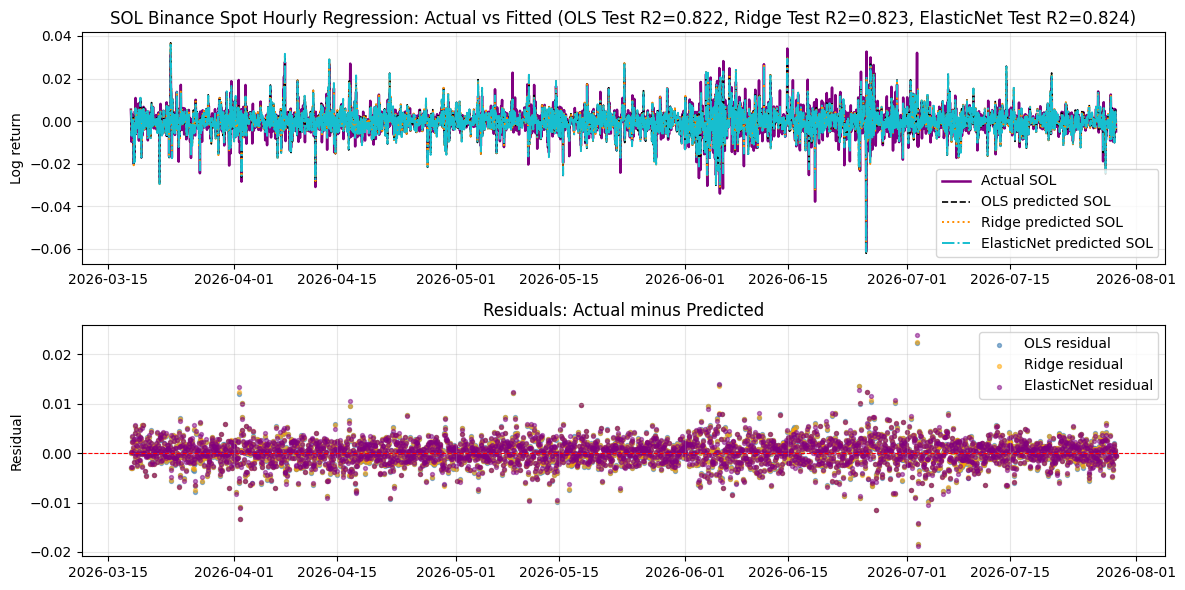

In [23]:
# Regression chart
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(test_data.index, y_test, label="Actual SOL", color=coin_colors["SOL"], linewidth=1.8)
axes[0].plot(test_data.index, y_pred, label="OLS predicted SOL", color="black", linestyle="--", linewidth=1.2)
axes[0].plot(test_data.index, ridge_y_pred, label="Ridge predicted SOL", color="darkorange", linestyle=":", linewidth=1.4)
axes[0].plot(test_data.index, elastic_net_y_pred, label="ElasticNet predicted SOL", color="tab:cyan", linestyle="-.", linewidth=1.4)
axes[0].set_title(
    f"SOL Binance Spot Hourly Regression: Actual vs Fitted "
    f"(OLS Test R2={test_r2:.3f}, Ridge Test R2={ridge_test_r2:.3f}, "
    f"ElasticNet Test R2={elastic_net_test_r2:.3f})"
)
axes[0].set_ylabel("Log return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
ridge_residuals = y_test - ridge_y_pred
elastic_net_residuals = y_test - elastic_net_y_pred
axes[1].scatter(test_data.index, residuals, s=8, color="steelblue", alpha=0.6, label="OLS residual")
axes[1].scatter(test_data.index, ridge_residuals, s=8, color="orange", alpha=0.5, label="Ridge residual")
axes[1].scatter(test_data.index, elastic_net_residuals, s=8, color="purple", alpha=0.5, label="ElasticNet residual")
axes[1].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[1].set_title("Residuals: Actual minus Predicted")
axes[1].set_ylabel("Residual")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Notebook-only outputs

This notebook displays tables, summaries, and charts inline. It does not save research CSV, TXT, or PNG output files.